## Exploratory Data Analysis
Author: Angela Palacino

### Conclusions
Cases of drug abuse in localities across Bogotá are highly dependent on the location of the locality when taking int acount the cases per habitants, therefore the graphs are presented as a percenage of cases per age group. It was found that the first four localities with most cases are located in an axe in the center of the city, they present more cases in the youth. To reduce these cases there should be efforts directed at the adolescence age group to prevent further problematic abuse of psychoactive substances, a behaviour observed in Tunjuelito (the fifth locality). Additionally, it is seen that fortunately there are very few cases in the first infancy. These graphs show there might be an association between the locality and age groups when it comes to drug abuse.

The purpose of this analysis is to explore the behaviour of psychoactive drug abuse in the different localities in Bogotá, taking into account the population in each of them.
How does the age group relate to  this consumption for a specific year, in the 5 localities with the most consumption.

For reference the age groups in the psychoactive drug abuse data set are:
- Primera infancia(First infancy): 0-5 years
- Infancia(Infancy): 6-11 years
- Adolescencia(Adolescence): 12-16 years
- Juventud(Youth): 17-26 years
- Adultez(Adulthood): 27-59 year
- Vejez(Elderly): 60+ years

### Data import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Uploading data
psycho_substance = pd.read_parquet(
    "/home/ange/DS_projects/psycho_substance_abuse/data/raw/psycho_substance.parquet.gzip",
    engine="pyarrow",
)
population = pd.read_parquet(
    "/home/ange/DS_projects/psycho_substance_abuse/data/raw/population.parquet.gzip",
    engine="pyarrow",
)

In [3]:
psycho_substance.head()

,ANO,SEXO,NOMBRELOCALIDADRESIDENCIA,MESNOTIFICACION,TRIMESTRE,TIPOASEGURAMIENTO,SITIOHABITUALCONSUMO_VIVIENDA,SITIOHABITUALCONSUMO_PARQUE,SITIOHABITUALCONSUMO_EST_EDUCATIVO,SITIOHABITUALCONSUMO_BARES_TABERNAS,...,SITIOHABITUALCONSUMO_CASA_AMIGOS,NIVELEDUCATIVO,CURSO_DE_VIDA,COMOACUDIOTRATAMIENTO,PERTENENCIAETNICA,ORIENTSEXUAL,PAISNACIONALIDAD,NOMBREUPZ,ESTADOCIVIL,CASOS
0,2022.0,Hombre,Ciudad Bolívar,6.0,2.0,Subsidiado,SI,SI,NO,SI,...,SI,6. Secundaria completa,Adultez,1. Voluntariamente,AfroColombianos,Homosexual,Sin Dato,LUCERO,1. Soltero (a),1.0
1,2022.0,Hombre,Suba,7.0,3.0,Particular,SI,NO,NO,NO,...,NO,1. No fue a la escuela,Juventud,1. Voluntariamente,Otros,Heterosexual,Sin Dato,SUBA,1. Soltero (a),1.0
2,2022.0,Mujer,Mártires,7.0,3.0,Contributivo,NO,SI,NO,NO,...,NO,5. Secundaria incompleta,Adolescencia,2. Lo llevaron familiares,Otros,Heterosexual,Sin Dato,LA SABANA,1. Soltero (a),1.0
3,2022.0,Hombre,Fontibón,11.0,4.0,Contributivo,NO,SI,NO,NO,...,NO,8. Técnico post-secundaria completa,Adultez,1. Voluntariamente,Otros,Heterosexual,Sin Dato,CAPELLANIA,1. Soltero (a),2.0
4,2023.0,Hombre,Mártires,1.0,1.0,Subsidiado,NO,NO,NO,NO,...,SI,5. Secundaria incompleta,Adultez,1. Voluntariamente,Otros,Heterosexual,COLOMBIA,LA SABANA,1. Soltero (a),13.0


In [4]:
population.head()

,Año,Cod_Loc,Localidad,Sexo,Edad,Grupo_Edad,Población
0,2005,1,Usaquén,Hombres,0,00 a 04,2909
1,2005,1,Usaquén,Hombres,1,00 a 04,2954
2,2005,1,Usaquén,Hombres,2,00 a 04,2919
3,2005,1,Usaquén,Hombres,3,00 a 04,2989
4,2005,1,Usaquén,Hombres,4,00 a 04,3079


### Processing of psychoactive drugs data set

In [5]:
# Filter the entries without a locality and null values
psycho_substance = psycho_substance[
    ~psycho_substance["NOMBRELOCALIDADRESIDENCIA"].isin(["Sin dato", "N.A."])
]
psycho_substance.dropna(subset=["NOMBRELOCALIDADRESIDENCIA"], inplace=True)

psycho_substance_year = psycho_substance.groupby(["ANO"])["CASOS"].sum()

In [6]:
# Find the names of the localities in the drugs data set to fix name mismatches
localities = set(psycho_substance["NOMBRELOCALIDADRESIDENCIA"].unique())

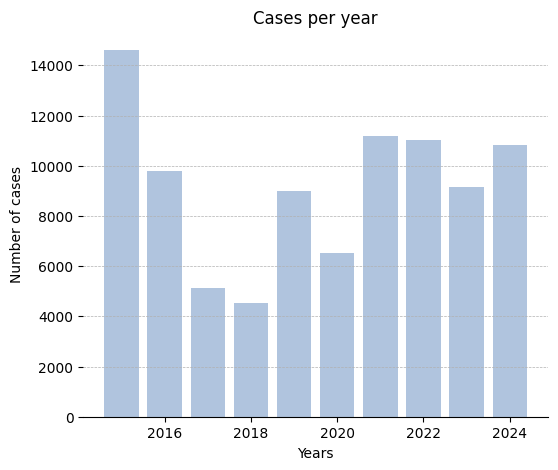

In [7]:
# Graph the number of cases per year
plt.figure(figsize=(6, 5))
plt.bar(psycho_substance_year.index, psycho_substance_year, color="lightsteelblue")
for spine in ["right", "top", "left"]:
    plt.gca().spines[spine].set_visible(False)
plt.grid(which="both", linestyle="--", linewidth=0.5, axis="y")
plt.title("Cases per year")
plt.ylabel("Number of cases")
plt.xlabel("Years");

In this first figure we can see the number of cases per year from 2015 to 2024, in order to analyze most recent data only the year 2024 will be used for the rest of the analysis. From this data set the data will be grouped by Locality and sorted to find the five localities with most cases. Later on the data set will be grouped by age groups to see the behaviour of these.

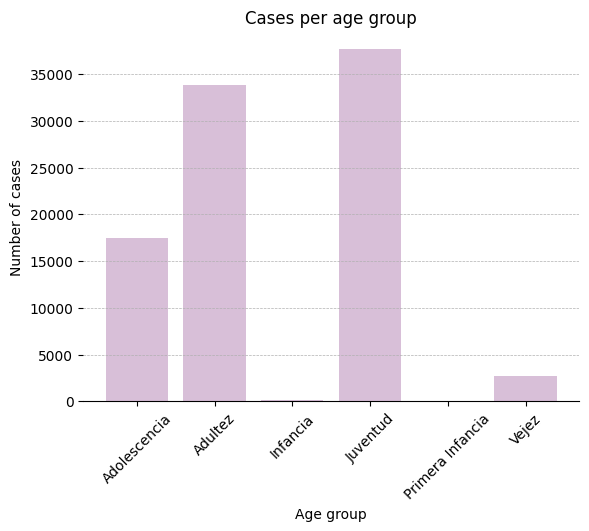

In [8]:
# Find the number of cases for each age group
psycho_substance_age = psycho_substance.groupby(["CURSO_DE_VIDA"])["CASOS"].sum()
# Plot the number of cases
plt.figure()
plt.bar(psycho_substance_age.index, psycho_substance_age, color="thistle")
x = plt.gca().xaxis
for item in x.get_ticklabels():
    item.set_rotation(45)
for spine in ["right", "top", "left"]:
    plt.gca().spines[spine].set_visible(False)
plt.grid(which="both", linestyle="--", linewidth=0.5, axis="y")
plt.title("Cases per age group")
plt.ylabel("Number of cases")
plt.xlabel("Age group");

From the previous figure we can see the most cases are presented in the age groups of adolescence, youth and adulthood. There are hardly any cases in the first infancy, so these will be removed from further analysis.

In [9]:
# Find the cases by age group and locality
cases_by_age_loc = psycho_substance[psycho_substance["ANO"] == 2024]
cases_by_age_loc = psycho_substance.groupby(
    ["NOMBRELOCALIDADRESIDENCIA", "CURSO_DE_VIDA"]
)["CASOS"].sum()
cases_by_age_loc = cases_by_age_loc.reset_index()
age_groups = {
    "Primera infancia": "First infancy",
    "Infancia": "Infancy",
    "Adolescencia": "Adolescence",
    "Juventud": "Youth",
    "Adultez": "Adulthood",
    "Vejez": "Elderly",
}
cases_by_age_loc.replace(age_groups, inplace=True)
cases_by_age_loc

,NOMBRELOCALIDADRESIDENCIA,CURSO_DE_VIDA,CASOS
0,Antonio Nariño,Adolescence,94.0
1,Antonio Nariño,Adulthood,597.0
2,Antonio Nariño,Youth,462.0
3,Antonio Nariño,Elderly,85.0
4,Barrios Unidos,Adolescence,182.0
...,...,...,...
90,Usme,Adolescence,2208.0
91,Usme,Adulthood,1101.0
92,Usme,Infancy,17.0
93,Usme,Youth,2207.0


For the population data set it is necessary to filter for the year 2024, add a column with the age groups according to the groups from the pyschoactive drug abuse data set then group by locality and age group.

### Processing of population data set

In [10]:
# Filter the population for the year 2024
population_2024 = population[population["Año"] == 2024]

In [11]:
conditions = [
    (population_2024["Edad"] >= 0) & (population_2024["Edad"] <= 5),
    (population_2024["Edad"] >= 6) & (population_2024["Edad"] <= 11),
    (population_2024["Edad"] >= 12) & (population_2024["Edad"] <= 16),
    (population_2024["Edad"] >= 17) & (population_2024["Edad"] <= 26),
    (population_2024["Edad"] >= 27) & (population_2024["Edad"] <= 59),
    (population_2024["Edad"] > 59),
]

labels = ["First infancy", "Infancy", "Adolescence", "Youth", "Adulthood", "Elderly"]

In [12]:
# Create and age group column, replace locality values Bogotá with null and remove them
# Finally group by age and locality
population_2024.loc[:, "age_group"] = np.select(conditions, labels, default="Unknown")
population_2024.loc[:, "Localidad"] = population_2024["Localidad"].replace(
    "Bogotá", np.nan
)
population_2024 = population_2024.dropna(subset=["Localidad"])

/tmp/ipykernel_48254/2309577486.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population_2024.loc[:, "age_group"] = np.select(conditions, labels, default="Unknown")


In [13]:
# Find the localities in the population data set to fix name mismatches
localities_2 = set(population_2024["Localidad"].unique())

In [14]:
# Find the localities that are not present in the population data set
diff1 = list(localities - localities_2)
diff1.sort()
diff1

['Candelaria', 'Mártires', 'Rafael Uribe']

In [15]:
# Find the localities that are not present in the drug consumption data set
diff2 = list(localities_2 - localities)
diff2.sort()
diff2

['La Candelaria', 'Los Mártires', 'Rafael Uribe Uribe']

In [16]:
# Create the dictionary to replace name mismatches in the population data set
localities_dic = dict(zip(diff2, diff1))
localities_dic

{'La Candelaria': 'Candelaria',
 'Los Mártires': 'Mártires',
 'Rafael Uribe Uribe': 'Rafael Uribe'}

In [17]:
# Create and age group column, replace locality values Bogotá with null and remove them
# Finally group by age and locality

population_2024.replace(localities_dic, inplace=True)
population_age_loc = population_2024.groupby(["Localidad", "age_group"])[
    "Población"
].sum()
population_age_loc = population_age_loc.reset_index()
population_age_loc

,Localidad,age_group,Población
0,Antonio Nariño,Adolescence,4620
1,Antonio Nariño,Adulthood,39247
2,Antonio Nariño,Elderly,14532
3,Antonio Nariño,First infancy,9181
4,Antonio Nariño,Infancy,4843
...,...,...,...
115,Usme,Adulthood,183713
116,Usme,Elderly,51206
117,Usme,First infancy,44135
118,Usme,Infancy,35975


### Creation and Descriptive analysis of final data set

In [18]:
# merge data from population_age_loc and cases_by_age_loc
sust_pop_age_loc = population_age_loc.merge(
    cases_by_age_loc,
    how="left",
    left_on=["Localidad", "age_group"],
    right_on=["NOMBRELOCALIDADRESIDENCIA", "CURSO_DE_VIDA"],
)
sust_pop_age_loc = sust_pop_age_loc.groupby(["Localidad", "age_group"]).sum()
# Save primary data for further analysis
processed_df = sust_pop_age_loc[["CASOS", "Población"]].copy()
processed_df = processed_df.reset_index()
processed_df.to_parquet(
    "/home/ange/DS_projects/psycho_substance_abuse/data/processed/master_population_cases.parquet.gzip",
    compression="gzip",
    engine="pyarrow",
)
sust_pop_age_loc.head()

Población NOMBRELOCALIDADRESIDENCIA  \
Localidad      age_group                                            
Antonio Nariño Adolescence         4620            Antonio Nariño   
               Adulthood          39247            Antonio Nariño   
               Elderly            14532            Antonio Nariño   
               First infancy       9181                         0   
               Infancy             4843                         0   

                             CURSO_DE_VIDA  CASOS  
Localidad      age_group                           
Antonio Nariño Adolescence     Adolescence   94.0  
               Adulthood         Adulthood  597.0  
               Elderly             Elderly   85.0  
               First infancy             0    0.0  
               Infancy                   0    0.0

In [19]:
# Find the top 5 localities with abuse cases
casesby1k = sust_pop_age_loc[["CASOS", "Población"]]
casesby1k = casesby1k.reset_index()
casesby1k = casesby1k[["Localidad", "CASOS", "Población"]]
casesby1k = casesby1k.groupby(["Localidad"]).sum()
casesby1k["Cases/population"] = casesby1k["CASOS"] / casesby1k["Población"] * 1000
casesby1k.sort_values(by=["Cases/population"], ascending=False, inplace=True)
top_five = casesby1k.index[0:5]
top_five

Index(['Mártires', 'Candelaria', 'Santa Fe', 'Puente Aranda', 'Tunjuelito'], dtype='object', name='Localidad')

In [20]:
# Calculate percentage of cases, organize values and remove values of first infancy
sust_pop_age_loc["Cases_population"] = (
    sust_pop_age_loc["CASOS"] / sust_pop_age_loc["Población"] * 100
)
sust_pop_age_loc = sust_pop_age_loc.reset_index()
# Filter leaving only the five localities with most cases
sust_pop_age_loc = sust_pop_age_loc[sust_pop_age_loc["Localidad"].isin(top_five)]

# Have age group be the index
sust_pop_age_loc = sust_pop_age_loc.pivot(
    index="age_group", columns="Localidad", values="Cases_population"
)

# Sort the index
custom_dict = {
    "First Infancy": 0,
    "Infancy": 1,
    "Adolescence": 2,
    "Youth": 3,
    "Adulthood": 4,
    "Elderly": 5,
}
sust_pop_age_loc.sort_index(
    key=lambda x: x.map(custom_dict), ascending=False, inplace=True
)
sust_pop_age_loc = sust_pop_age_loc[~sust_pop_age_loc.index.isin(["First infancy"])]

sust_pop_age_loc

Localidad,Candelaria,Mártires,Puente Aranda,Santa Fe,Tunjuelito
age_group,,,,,
Elderly,2.654867,3.985603,0.463822,1.863740,0.335379
Adulthood,8.532185,14.878909,1.984770,7.012402,1.063557
Youth,19.478996,16.263238,6.009615,8.686754,5.099241
Adolescence,6.473988,4.531508,2.656969,4.718571,8.033012
Infancy,0.123001,0.018235,0.006675,0.065096,0.015286


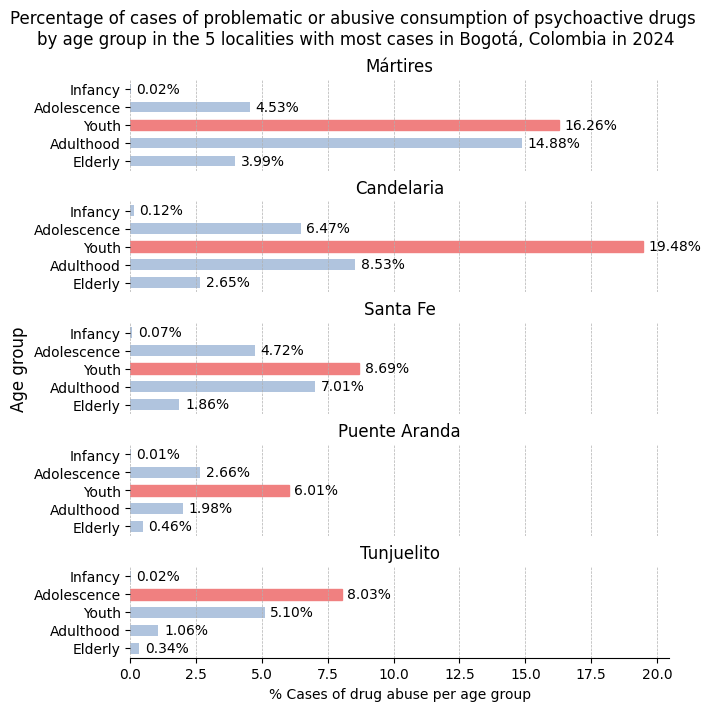

In [ ]:
figure, axs = plt.subplots(
    nrows=5,
    sharex=True,
    sharey=True,
    figsize=(7, 7),
    constrained_layout=True,
    facecolor="white",
)

figure.suptitle(
    "Percentage of cases of problematic or abusive consumption of psychoactive drugs \n"
    "by age group in the 5 localities with most cases in Bogotá, Colombia in 2024",
    fontsize="large",
)

# Plot loop for 5 subplots
for i in range(5):
    ax = axs[i]
    locality = top_five[i]
    values = sust_pop_age_loc[locality]

    bars = ax.barh(sust_pop_age_loc.index, values, height=0.6, color="lightsteelblue")

    # Find index of max value
    max_idx = values.argmax()
    bars[max_idx].set_color("lightcoral")  # highlight max value

    ax.set_title(locality)
    ax.grid(which="both", linestyle="--", linewidth=0.5, axis="x")
    ax.bar_label(bars, label_type="edge", padding=4, fmt="%0.2f%%")

    for spine_name, spine in ax.spines.items():
        if not (i == 4 and spine_name == "bottom"):
            spine.set_visible(False)

    # Add y-label only to middle plot
    if i == 2:
        ax.set_ylabel("Age group", fontsize="large")

    # Add x-label only to last plot
    if i == 4:
        ax.set_xlabel("% Cases of drug abuse per age group", fontsize="medium")
        ax.tick_params(axis="x", which="both", bottom=True, top=False, labelbottom=True)
    else:
        ax.tick_params(
            axis="x", which="both", bottom=False, top=False, labelbottom=False
        )

plt.savefig(
    "/home/ange/DS_projects/psycho_substance_abuse/reports/Barplot_per_locality.png",
    bbox_inches="tight",
)

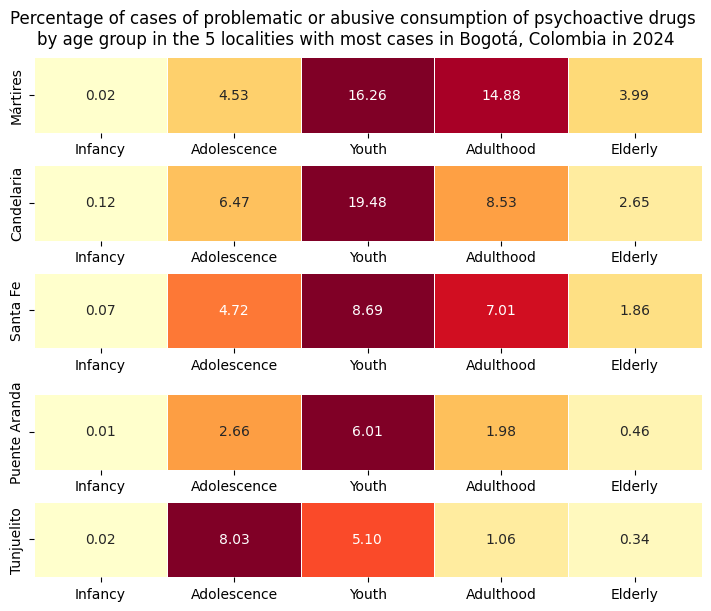

In [ ]:
sust_pop_age_loc = sust_pop_age_loc[::-1]
fig, axs = plt.subplots(nrows=5, figsize=(7, 6), constrained_layout=True)

for i, locality in enumerate(top_five):
    sns.heatmap(
        sust_pop_age_loc[[locality]].T,  # transpose so age groups are columns
        ax=axs[i],
        annot=True,
        cmap="YlOrRd",
        cbar=False,
        linewidths=0.5,
        fmt=".2f",
    )
    # axs[i].set_title(locality)
    axs[i].set_ylabel("")  # optional
    axs[i].set_xlabel("")  # optional

fig.suptitle(
    "Percentage of cases of problematic or abusive consumption of psychoactive drugs \n"
    "by age group in the 5 localities with most cases in Bogotá, Colombia in 2024",
    fontsize="large",
)
plt.savefig(
    "/home/ange/DS_projects/psycho_substance_abuse/reports/Heatmap_per_locality.png",
    bbox_inches="tight",
)
plt.show()

Finally, the data is presented as percentage of cases in each age group (number of cases in age group/total population of locality) for each of the localities with most cases. The first four localities with most cases are located in an axe in the center of the city, and they present more cases in the youth. Specially La Candelaria which has almost 10 percentage points above the following age groups, like adolescence and adulthood. To reduce these cases there should be efforts directed at the adolescence age group to prevent further problematic abuse of psychoactive substances, a behaviour observed in Tunjuelito (the fifth locality). Additionally, it is seen that fortunately there are very few cases in the first infancy. We can also see that in the elderly the first three localities (Mártires, Candelaria and Santa Fe) have a percentage of cases above 1% that is not seen in the other localities. These graphs show there might be an association between the locality and age groups when it comes to drug abuse.